# Drift Detection: Monitoring Non-Stationary Streams

In many production environments — high-frequency trading, IoT sensor networks, clickstream analytics — observing drift is not enough. The system must actively adapt to a changing reality.

This is the challenge of **concept drift**: the joint distribution $P_t(X, y)$ no longer equals $P_{t+k}(X, y)$. Consumer preferences shift (covariate shift), economic regimes change (concept drift), sensors degrade.

In this notebook we implement **active drift detection** with the **ADWIN** (ADaptive WINdowing) algorithm from [`river`](https://riverml.xyz/). ADWIN maintains a sliding window of variable size and automatically shrinks the window when the means of two sub-windows differ significantly. It is parameter-free with respect to window size, adapting to the scale of the drift naturally.

## The ADWIN detector

We wrap ADWIN in a small generator that consumes a stream of scalar values (e.g., model error rates, sensor readings) and yields the index and value at every point where drift is detected. In production, this yield would trigger a retraining job or switch traffic to a fallback model.

In [1]:
from typing import Generator, Tuple

import numpy as np
from river import drift


def monitor_stream_for_drift(
    data_stream: list[float],
    sensitivity: float = 0.002,
) -> Generator[Tuple[int, float], None, None]:
    """Detect concept drift in a numeric stream using ADWIN.

    ADWIN (ADaptive WINdowing) automatically adjusts its window size
    to detect changes in the data distribution.

    Args:
        data_stream: A list of numeric values (e.g., error rates, sensor values).
        sensitivity: The delta parameter for ADWIN; lower is more sensitive.

    Yields:
        Tuple of (index, value) where drift was detected.
    """
    adwin = drift.ADWIN(delta=sensitivity)

    for i, val in enumerate(data_stream):
        adwin.update(val)
        if adwin.drift_detected:
            yield (i, val)

## Simulate a regime shift

We generate 1,000 samples from a stable regime (mean = 0.5) followed by 1,000 samples from a shifted regime (mean = 0.8). ADWIN should flag the transition near index 1,000. The exact detection delay is a trade-off controlled by the `delta` parameter: lower delta = more sensitive = more false alarms.

In [2]:
# Generate stable data (mean=0.5) followed by a sudden shift (mean=0.8)
rng = np.random.default_rng(42)
stable_regime = rng.normal(0.5, 0.05, 1000)
shifted_regime = rng.normal(0.8, 0.05, 1000)
synthetic_stream = np.concatenate([stable_regime, shifted_regime])

print("Starting stream monitoring...")
alerts = list(monitor_stream_for_drift(synthetic_stream.tolist()))
for idx, value in alerts[:10]:
    print(f"ALERT: Drift detected at index {idx} (Value: {value:.3f})")
print(f"\nTotal alerts: {len(alerts)}")
print(f"First alert index: {alerts[0][0] if alerts else 'None'} (true shift at 1000)")

Starting stream monitoring...
ALERT: Drift detected at index 1055 (Value: 0.874)

Total alerts: 1
First alert index: 1055 (true shift at 1000)


## Visualizing the stream and alerts

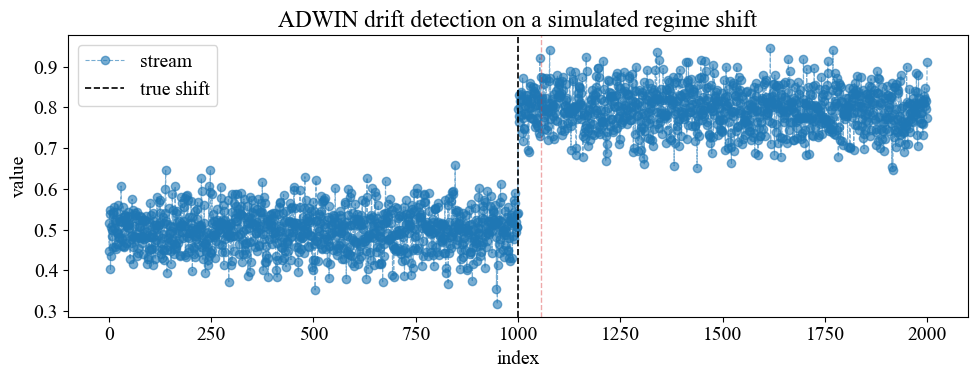

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(synthetic_stream, color="tab:blue", alpha=0.6, linewidth=0.8, label="stream")
ax.axvline(1000, color="black", linestyle="--", label="true shift")
for idx, _ in alerts:
    ax.axvline(idx, color="tab:red", alpha=0.4, linewidth=1)
ax.set_xlabel("index")
ax.set_ylabel("value")
ax.set_title("ADWIN drift detection on a simulated regime shift")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Choosing the right strategy

The right drift strategy depends on the domain and the cost of false positives:

| Scenario              | Recommended Approach     | Industry Example |
|-----------------------|--------------------------|------------------|
| Abrupt drift / regimes| Active Detection (ADWIN) | Algo trading: switch from "trend following" to "mean reversion" |
| Gradual / incremental | Passive (online learning)| IoT / manufacturing: sensors slowly degrading |
| Recurring / seasonal  | Ensemble methods         | Retail: dynamically weight a "winter" and "summer" model |
| Delayed labels        | Unsupervised (K-S test)  | Credit scoring: monitor applicant feature distribution |

In a real Airflow or Kubeflow pipeline, the detector runs as a sensor task: on a drift signal, it triggers a DAG that re-queries the feature store, builds a fresh training set, and launches a distributed retraining job.